# Simple Question Answering with a Neural Network
## bAbI Task 1 — Single Supporting Fact

This notebook builds a small neural network that answers simple questions from a short story.

Example:

```text
Story:
Mary went to the kitchen.
John went to the hallway.

Question:
Where is Mary?

Answer:
kitchen
```

We use **bAbI Task 1**, which focuses on answering questions that require one supporting fact.

### Learning objectives
1. Understand the structure of a simple Q&A dataset.
2. Convert text into token IDs.
3. Learn what an **Embedding** layer does.
4. Learn what an **LSTM** layer does.
5. Combine a story and question in one model.
6. Predict an answer using Softmax.
7. Test the model with your own story and question.

> This is **classification-based Q&A**, not free-form text generation.  
> The model selects an answer from a fixed vocabulary learned during training.

## 1. Import libraries

In [1]:
import os
import re
import tarfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

tf.keras.utils.set_random_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# Part A — Understanding the Dataset

A raw bAbI example looks approximately like:

```text
1 Mary moved to the bathroom.
2 John went to the hallway.
3 Where is Mary?    bathroom    1
```

The question line contains:

```text
question    answer    supporting-line-number
```

So in the example above:
- Question: `Where is Mary?`
- Answer: `bathroom`
- Supporting fact: line `1`

## 2. Download bAbI

In [2]:
DATA_URL = "https://s3.amazonaws.com/text-datasets/babi_tasks_1-20_v1-2.tar.gz"

path = keras.utils.get_file(
    fname="babi_tasks_1-20_v1-2.tar.gz",
    origin=DATA_URL
)

print("Downloaded to:", path)

11745123/11745123 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Downloaded to: /root/.keras/datasets/babi_tasks_1-20_v1-2.tar.gz


## 3. Read Task 1

In [3]:
tar = tarfile.open(path)

train_member = "tasks_1-20_v1-2/en-10k/qa1_single-supporting-fact_train.txt"
test_member = "tasks_1-20_v1-2/en-10k/qa1_single-supporting-fact_test.txt"

train_text = tar.extractfile(train_member).read().decode("utf-8")
test_text = tar.extractfile(test_member).read().decode("utf-8")

print("\n".join(train_text.splitlines()[:12]))

1 Mary moved to the bathroom.
2 John went to the hallway.
3 Where is Mary? 	bathroom	1
4 Daniel went back to the hallway.
5 Sandra moved to the garden.
6 Where is Daniel? 	hallway	4
7 John moved to the office.
8 Sandra journeyed to the bathroom.
9 Where is Daniel? 	hallway	4
10 Mary moved to the hallway.
11 Daniel travelled to the office.
12 Where is Daniel? 	office	11


## 4. Parse the raw data

For each question, we create:

| Story | Question | Answer |
|---|---|---|
| Mary went to the kitchen. John went to the hallway. | Where is Mary? | kitchen |

In [4]:
def parse_babi(text):
    examples = []
    story = []

    for raw_line in text.strip().splitlines():
        nid_text, content = raw_line.strip().split(" ", 1)
        nid = int(nid_text)

        if nid == 1:
            story = []

        if "\t" in content:
            question, answer, supporting = content.split("\t")

            examples.append({
                "story": " ".join(story),
                "question": question,
                "answer": answer,
                "supporting": supporting
            })
        else:
            story.append(content)

    return pd.DataFrame(examples)

train_df = parse_babi(train_text)
test_df = parse_babi(test_text)

print("Training examples:", len(train_df))
print("Test examples:", len(test_df))

train_df.head()

Training examples: 10000
Test examples: 1000


,story,question,answer,supporting
0,Mary moved to the bathroom. John went to the h...,Where is Mary?,bathroom,1
1,Mary moved to the bathroom. John went to the h...,Where is Daniel?,hallway,4
2,Mary moved to the bathroom. John went to the h...,Where is Daniel?,hallway,4
3,Mary moved to the bathroom. John went to the h...,Where is Daniel?,office,11
4,Mary moved to the bathroom. John went to the h...,Where is Sandra?,bathroom,8


## 5. Inspect examples

In [5]:
for i in range(5):
    print("=" * 70)
    print("STORY:")
    print(train_df.loc[i, "story"])
    print("\nQUESTION:")
    print(train_df.loc[i, "question"])
    print("\nANSWER:")
    print(train_df.loc[i, "answer"])

STORY:
Mary moved to the bathroom. John went to the hallway.

QUESTION:
Where is Mary? 

ANSWER:
bathroom
STORY:
Mary moved to the bathroom. John went to the hallway. Daniel went back to the hallway. Sandra moved to the garden.

QUESTION:
Where is Daniel? 

ANSWER:
hallway
STORY:
Mary moved to the bathroom. John went to the hallway. Daniel went back to the hallway. Sandra moved to the garden. John moved to the office. Sandra journeyed to the bathroom.

QUESTION:
Where is Daniel? 

ANSWER:
hallway
STORY:
Mary moved to the bathroom. John went to the hallway. Daniel went back to the hallway. Sandra moved to the garden. John moved to the office. Sandra journeyed to the bathroom. Mary moved to the hallway. Daniel travelled to the office.

QUESTION:
Where is Daniel? 

ANSWER:
office
STORY:
Mary moved to the bathroom. John went to the hallway. Daniel went back to the hallway. Sandra moved to the garden. John moved to the office. Sandra journeyed to the bathroom. Mary moved to the hallway. Dan

# Part B — Text Must Become Numbers

Neural networks cannot directly process words.

For example:

```text
Mary went to the kitchen
```

might become:

```text
mary    → 1
went    → 2
to      → 3
the     → 4
kitchen → 5
```

and therefore:

```text
[1, 2, 3, 4, 5]
```

These numbers are called **token IDs**.

## 6. Build a tokenizer

In [6]:
tokenizer = tf.keras.preprocessing.text.Tokenizer(
    lower=True,
    oov_token="<OOV>"
)

all_training_text = (
    train_df["story"].tolist()
    + train_df["question"].tolist()
)

tokenizer.fit_on_texts(all_training_text)

word_index = tokenizer.word_index
vocab_size = len(word_index) + 1

print("Vocabulary size:", vocab_size)
print()

for word, idx in list(word_index.items())[:20]:
    print(f"{word:12s} -> {idx}")

Vocabulary size: 21

<OOV>        -> 1
to           -> 2
the          -> 3
went         -> 4
john         -> 5
mary         -> 6
sandra       -> 7
daniel       -> 8
journeyed    -> 9
travelled    -> 10
back         -> 11
moved        -> 12
hallway      -> 13
bathroom     -> 14
garden       -> 15
where        -> 16
is           -> 17
office       -> 18
kitchen      -> 19
bedroom      -> 20


## 7. Example: sentence → token IDs

In [7]:
example_sentence = "Mary went to the kitchen"

example_tokens = tokenizer.texts_to_sequences(
    [example_sentence]
)[0]

print("Sentence:")
print(example_sentence)

print("\nToken IDs:")
print(example_tokens)

Sentence:
Mary went to the kitchen

Token IDs:
[6, 4, 2, 3, 19]


## 8. Convert stories and questions to token sequences

In [8]:
train_story_seq = tokenizer.texts_to_sequences(train_df["story"])
train_question_seq = tokenizer.texts_to_sequences(train_df["question"])

test_story_seq = tokenizer.texts_to_sequences(test_df["story"])
test_question_seq = tokenizer.texts_to_sequences(test_df["question"])

max_story_length = max(len(x) for x in train_story_seq)
max_question_length = max(len(x) for x in train_question_seq)

print("Maximum story length:", max_story_length)
print("Maximum question length:", max_question_length)

Maximum story length: 58
Maximum question length: 3


## 9. Padding

Stories do not all contain the same number of words.

Example:

```text
[12, 4, 8, 5]
[7, 3, 9, 2, 6, 11]
```

We pad shorter sequences with zeros:

```text
[0, 0, 12, 4, 8, 5]
[7, 3,  9, 2, 6, 11]
```

This gives every input in a batch the same shape.

In [10]:
X_story_train = tf.keras.utils.pad_sequences(
    train_story_seq,
    maxlen=max_story_length,
    padding="pre"
)

X_question_train = tf.keras.utils.pad_sequences(
    train_question_seq,
    maxlen=max_question_length,
    padding="pre"
)

X_story_test = tf.keras.utils.pad_sequences(
    test_story_seq,
    maxlen=max_story_length,
    padding="pre"
)

X_question_test = tf.keras.utils.pad_sequences(
    test_question_seq,
    maxlen=max_question_length,
    padding="pre"
)

print("Story training shape:", X_story_train.shape)
print("Question training shape:", X_question_train.shape)

Story training shape: (10000, 58)
Question training shape: (10000, 3)


# Part C — Answers Become Classes

The model selects one answer from a small set of locations.

This is similar to MNIST:

```text
MNIST:
image → one of 10 digit classes

bAbI:
story + question → one of several answer classes
```

In [11]:
answer_words = sorted(train_df["answer"].unique())

answer_to_id = {
    answer: i
    for i, answer in enumerate(answer_words)
}

id_to_answer = {
    i: answer
    for answer, i in answer_to_id.items()
}

y_train = train_df["answer"].map(answer_to_id).to_numpy()
y_test = test_df["answer"].map(answer_to_id).to_numpy()

num_answers = len(answer_words)

print("Possible answers:", answer_words)
print("\nNumber of classes:", num_answers)
print("\nMapping:")

for answer, idx in answer_to_id.items():
    print(f"{answer:12s} -> {idx}")

Possible answers: ['bathroom', 'bedroom', 'garden', 'hallway', 'kitchen', 'office']

Number of classes: 6

Mapping:
bathroom     -> 0
bedroom      -> 1
garden       -> 2
hallway      -> 3
kitchen      -> 4
office       -> 5


# Part D — New Layer: Embedding

Token IDs are only identifiers.

For example:

```text
mary → 17
```

The number `17` does not mean that Mary is mathematically larger than another word.

An **Embedding layer** converts each token ID into a trainable numerical vector.

Example:

```text
mary → 17
        ↓
[0.21, -0.48, 0.72, 0.10, ...]
```

If we use:

```python
Embedding(vocab_size, 32)
```

then **every word is represented by 32 learned values**.

These values are learned through backpropagation.

## 10. Embedding shape example

In [12]:
demo_embedding = layers.Embedding(
    input_dim=vocab_size,
    output_dim=32
)

demo_tokens = tf.constant([[1, 2, 3, 4]])
demo_vectors = demo_embedding(demo_tokens)

print("Input token IDs shape:", demo_tokens.shape)
print("Embedding output shape:", demo_vectors.shape)
print()
print("4 token IDs became 4 vectors with 32 values each.")

Input token IDs shape: (1, 4)
Embedding output shape: (1, 4, 32)

4 token IDs became 4 vectors with 32 values each.


# Part E — New Layer: LSTM

Text is sequential.

Compare:

```text
Mary followed John.
John followed Mary.
```

The words are similar, but their order changes the meaning.

An **LSTM (Long Short-Term Memory)** is a recurrent neural-network layer that reads a sequence step by step while carrying information from earlier steps.

Conceptually:

```text
Mary → went → to → the → kitchen
  ↓      ↓     ↓     ↓       ↓
       LSTM reads in order
                    ↓
          sequence representation
```

With:

```python
LSTM(64)
```

the layer produces a learned summary containing **64 values**.

You can think of it as converting a variable-length sequence of word embeddings into one fixed-size numerical representation.

## 11. LSTM shape example

In [13]:
demo_lstm = layers.LSTM(64)
demo_lstm_output = demo_lstm(demo_vectors)

print("Before LSTM:", demo_vectors.shape)
print("After LSTM:", demo_lstm_output.shape)

Before LSTM: (1, 4, 32)
After LSTM: (1, 64)


# Part F — Build the Q&A Model

The model has **two inputs**:

```text
Story                         Question
  ↓                              ↓
Embedding                     Embedding
  ↓                              ↓
LSTM                          LSTM
  ↓                              ↓
64 values                    64 values
    \                         /
     \                       /
       Concatenate
           ↓
       128 values
           ↓
        Dense
           ↓
       Softmax
           ↓
        Answer
```

## New Layer: Concatenate

`Concatenate` simply joins vectors.

Example:

```text
Story:    [0.1, 0.3, 0.8]
Question: [0.4, 0.2]

Combined:
[0.1, 0.3, 0.8, 0.4, 0.2]
```

## 12. Build the model

In [15]:
story_input = keras.Input(
    shape=(max_story_length,),
    name="story"
)

question_input = keras.Input(
    shape=(max_question_length,),
    name="question"
)

# Shared word embedding:
# the same word gets the same representation
# whether it appears in the story or question.
embedding = layers.Embedding(
    input_dim=vocab_size,
    output_dim=32,
    mask_zero=True,
    name="word_embedding"
)

story_embedded = embedding(story_input)
question_embedded = embedding(question_input)

story_encoded = layers.LSTM(
    64,
    name="story_lstm"
)(story_embedded)

question_encoded = layers.LSTM(
    64,
    name="question_lstm"
)(question_embedded)

combined = layers.Concatenate(
    name="combine_story_question"
)([story_encoded, question_encoded])

x = layers.Dense(
    64,
    activation="relu",
    name="reasoning_dense"
)(combined)

x = layers.Dropout(
    0.2,
    name="dropout"
)(x)

answer_output = layers.Dense(
    num_answers,
    activation="softmax",
    name="answer"
)(x)

qa_model = keras.Model(
    inputs=[story_input, question_input],
    outputs=answer_output
)

qa_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ story (InputLayer)  │ (None, 58)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ question            │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, 3, 32)     │        672 │ story[0][0],      │
│ (Embedding)         │                   │            │ question[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 58)        │          0 │ story[0][0]       │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_3         │ (None, 3)         │          0 │ question[0][0]    │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ story_lstm (LSTM)   │ (None, 64)        │     24,832 │ word_embedding[0… │
│                     │                   │            │ not_equal_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ question_lstm       │ (None, 64)        │     24,832 │ word_embedding[1… │
│ (LSTM)              │                   │            │ not_equal_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ combine_story_ques… │ (None, 128)       │          0 │ story_lstm[0][0], │
│ (Concatenate)       │                   │            │ question_lstm[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reasoning_dense     │ (None, 64)        │      8,256 │ combine_story_qu… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ reasoning_dense[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ answer (Dense)      │ (None, 6)         │        390 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 58,982 (230.40 KB)

 Trainable params: 58,982 (230.40 KB)

 Non-trainable params: 0 (0.00 B)

## 13. What does the Softmax output mean?

Suppose the possible answer classes are:

```text
bathroom
bedroom
garden
hallway
kitchen
office
```

The model might output:

```text
bathroom → 0.01
bedroom  → 0.02
garden   → 0.03
hallway  → 0.02
kitchen  → 0.89
office   → 0.03
```

The largest probability is `kitchen`, so that becomes the prediction.

## 14. Compile the model

In [16]:
qa_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 15. Train the model

In [17]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True
)

history = qa_model.fit(
    {
        "story": X_story_train,
        "question": X_question_train
    },
    y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 13s 59ms/step - accuracy: 0.4238 - loss: 1.5394 - val_accuracy: 0.5430 - val_loss: 1.2804
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - accuracy: 0.5326 - loss: 1.2251 - val_accuracy: 0.5250 - val_loss: 1.1833
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.5328 - loss: 1.1439 - val_accuracy: 0.5140 - val_loss: 1.1279
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - accuracy: 0.5312 - loss: 1.1137 - val_accuracy: 0.5180 - val_loss: 1.1031


## 16. Plot training accuracy

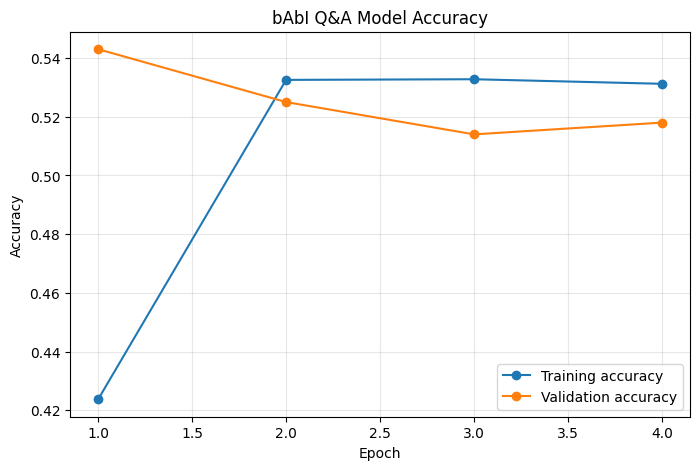

In [19]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(8, 5))

plt.plot(
    history_df.index + 1,
    history_df["accuracy"],
    marker="o",
    label="Training accuracy"
)

plt.plot(
    history_df.index + 1,
    history_df["val_accuracy"],
    marker="o",
    label="Validation accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("bAbI Q&A Model Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 17. Evaluate on unseen test data

In [20]:
test_loss, test_accuracy = qa_model.evaluate(
    {
        "story": X_story_test,
        "question": X_question_test
    },
    y_test,
    verbose=0
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.2%}")

Test loss: 1.2970
Test accuracy: 51.90%


# Part G — Inspect Predictions

In [21]:
probabilities = qa_model.predict(
    {
        "story": X_story_test[:20],
        "question": X_question_test[:20]
    },
    verbose=0
)

predicted_ids = np.argmax(probabilities, axis=1)

predicted_answers = [
    id_to_answer[i]
    for i in predicted_ids
]

results = pd.DataFrame({
    "Story": test_df["story"].iloc[:20].values,
    "Question": test_df["question"].iloc[:20].values,
    "Actual Answer": test_df["answer"].iloc[:20].values,
    "Predicted Answer": predicted_answers,
    "Confidence": np.max(probabilities, axis=1)
})

results

,Story,Question,Actual Answer,Predicted Answer,Confidence
0,John travelled to the hallway. Mary journeyed ...,Where is John?,hallway,bathroom,0.404445
1,John travelled to the hallway. Mary journeyed ...,Where is Mary?,bathroom,bedroom,0.485415
2,John travelled to the hallway. Mary journeyed ...,Where is Sandra?,kitchen,kitchen,0.348904
3,John travelled to the hallway. Mary journeyed ...,Where is Sandra?,hallway,garden,0.432631
4,John travelled to the hallway. Mary journeyed ...,Where is Sandra?,kitchen,kitchen,0.489406
5,Sandra travelled to the kitchen. Sandra travel...,Where is Sandra?,hallway,hallway,0.451480
6,Sandra travelled to the kitchen. Sandra travel...,Where is Sandra?,garden,garden,0.476171
7,Sandra travelled to the kitchen. Sandra travel...,Where is Daniel?,hallway,hallway,0.391687
8,Sandra travelled to the kitchen. Sandra travel...,Where is Sandra?,office,hallway,0.410746
9,Sandra travelled to the kitchen. Sandra travel...,Where is Daniel?,office,office,0.482323


## 18. Inspect one prediction

In [22]:
i = 0

print("STORY:")
print(results.loc[i, "Story"])

print("\nQUESTION:")
print(results.loc[i, "Question"])

print("\nACTUAL ANSWER:")
print(results.loc[i, "Actual Answer"])

print("\nPREDICTED ANSWER:")
print(results.loc[i, "Predicted Answer"])

print("\nCONFIDENCE:")
print(f"{results.loc[i, 'Confidence']:.2%}")

STORY:
John travelled to the hallway. Mary journeyed to the bathroom.

QUESTION:
Where is John? 

ACTUAL ANSWER:
hallway

PREDICTED ANSWER:
bathroom

CONFIDENCE:
40.44%


# Part H — Ask Your Own Question

The function below follows the same pipeline used during training:

```text
Raw story + question
        ↓
Tokenizer
        ↓
Token IDs
        ↓
Padding
        ↓
Embedding
        ↓
LSTM
        ↓
Softmax
        ↓
Predicted answer
```

For best results, use the same style and vocabulary as the bAbI dataset.

Example:

```text
Mary went to the kitchen.
John went to the hallway.

Where is Mary?
```

In [23]:
def ask_babi_model(story, question, model=qa_model):
    story_seq = tokenizer.texts_to_sequences([story])
    question_seq = tokenizer.texts_to_sequences([question])

    story_array = tf.keras.utils.pad_sequences(
        story_seq,
        maxlen=max_story_length,
        padding="pre"
    )

    question_array = tf.keras.utils.pad_sequences(
        question_seq,
        maxlen=max_question_length,
        padding="pre"
    )

    probs = model.predict(
        {
            "story": story_array,
            "question": question_array
        },
        verbose=0
    )[0]

    predicted_id = int(np.argmax(probs))
    predicted_answer = id_to_answer[predicted_id]
    confidence = float(probs[predicted_id])

    return predicted_answer, confidence, probs

## 19. Custom example

In [35]:
my_story = "Mary went to the kitchen. John went to the hallway."
# my_story = "Mary went to the kitchen. Miguel went to the office."
my_question = "Where is Mary?"

prediction, confidence, probs = ask_babi_model(
    my_story,
    my_question
)

print("STORY:")
print(my_story)

print("\nQUESTION:")
print(my_question)

print("\nPREDICTION:")
print(prediction)

print("\nCONFIDENCE:")
print(f"{confidence:.2%}")

STORY:
Mary went to the kitchen. John went to the hallway.

QUESTION:
Where is Mary?

PREDICTION:
hallway

CONFIDENCE:
41.58%


## 20. Try another example

In [36]:
my_story = (
    "Daniel went to the office. "
    "Sandra went to the garden. "
    "John went to the bathroom."
)

my_question = "Where is Sandra?"

prediction, confidence, probs = ask_babi_model(
    my_story,
    my_question
)

print("Prediction:", prediction)
print(f"Confidence: {confidence:.2%}")

Prediction: bathroom
Confidence: 37.47%


## 21. View all answer probabilities

In [37]:
probability_table = pd.DataFrame({
    "Answer": [id_to_answer[i] for i in range(num_answers)],
    "Probability": probs
}).sort_values(
    "Probability",
    ascending=False
)

probability_table

,Answer,Probability
0,bathroom,0.374731
5,office,0.310387
2,garden,0.174818
3,hallway,0.057111
4,kitchen,0.049301
1,bedroom,0.033653


# Part I — Connection to MNIST

The logic is surprisingly similar.

### MNIST

```text
Image
  ↓
Pixel numbers
  ↓
Neural network
  ↓
Softmax
  ↓
Digit class
```

### bAbI

```text
Story + question
      ↓
Token IDs
      ↓
Embeddings
      ↓
LSTMs
      ↓
Dense layer
      ↓
Softmax
      ↓
Answer class
```

In both cases:

> **Convert input to numbers → learn representations → calculate probabilities → choose a class**

# Part J — How Is This Different from an LLM?

This model is useful for understanding neural networks for language, but it is **not a large language model**.

This model:
- has a small vocabulary;
- solves a narrow task;
- uses LSTMs;
- predicts from a fixed answer vocabulary;
- does not freely generate sentences.

Modern LLMs typically:
- use much larger vocabularies;
- train on enormous text corpora;
- use Transformer architectures;
- predict tokens;
- generate sequences of new text.

A useful progression is:

```text
ANN
 ↓
Text tokenization
 ↓
Embeddings
 ↓
Sequence models such as LSTM
 ↓
Simple Q&A
 ↓
Attention / Transformers
 ↓
Large Language Models
```

# Discussion Questions

1. Why can raw words not be passed directly into this neural network?
2. What is the difference between a token ID and an embedding?
3. Why do we need padding?
4. What does an LSTM try to retain while reading a sentence?
5. Why does the model have separate story and question inputs?
6. What does `Concatenate` do?
7. Why is Softmax used for the output?
8. Is this model generating an answer or classifying one?
9. What could happen if we use a word the model never saw during training?
10. How is this model different from a Transformer-based LLM?

# Key Takeaways

- Text must be converted to numerical representations before a neural network can process it.
- **Tokenization** converts words into IDs.
- **Embeddings** convert word IDs into learned vectors.
- **LSTMs** process sequences while carrying information forward.
- Story and question representations can be combined for simple Q&A.
- Softmax turns the task into multiclass answer classification.
- This is a useful bridge between traditional neural networks and modern language models.